# 03 — Oil Price Cap Effectiveness: Did the $60 G7+EU Cap Bind?

**Question.** The December 2022 G7+EU price cap on Russian crude at **$60/bbl** was
unprecedented — a price control enforced through control of shipping/insurance
services rather than a trade ban. Did it actually bind (force Urals to trade at or
below $60), and how does the realized Urals price compare to a counterfactual of
"no cap, historical discount persists"?

**Approach.**
1. Establish the **pre-war historical Urals-Brent discount** baseline (the task
   specifies "2%" as a reference; we also compute the discount actually observed in
   this data and compare the two).
2. Build a **counterfactual price**: `Brent − historical discount`, for every quarter
   from Q1 2023 (first full quarter after the 5 Dec 2022 implementation) onward.
3. Compare **actual quarterly average Urals price** against (a) the $60 cap level and
   (b) the counterfactual.
4. Quantify the **implied per-barrel and aggregate revenue loss** relative to the
   counterfactual.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11,4.5)
plt.rcParams['axes.titleweight'] = 'bold'

DATA = '.'
CAP_LEVEL = 60.0          # USD/bbl, G7+EU price cap, effective 2022-12-05
CAP_DATE = pd.Timestamp('2022-12-05')


## 1. Load data & establish the pre-war baseline discount

In [2]:
daily = pd.read_csv(f'{DATA}/commodities_daily.csv', parse_dates=['date'])
macro = pd.read_csv(f'{DATA}/macro_monthly.csv')
macro['date'] = pd.to_datetime(macro['year_month'])

pre_war_daily = daily[daily.date < '2022-02-24']
baseline_usd = pre_war_daily.urals_brent_spread_usd.mean()
baseline_pct = 100 * baseline_usd / pre_war_daily.brent_usd_bbl.mean()

print(f'Empirically observed pre-war (<2022-02-24) mean Urals-Brent discount: '
      f'{baseline_usd:.2f} USD/bbl  (~{baseline_pct:.2f}% of Brent)')
print(f'Task-specified reference discount: 2.0% of Brent')
print()
print('These are close (empirical ~3.0% vs specified 2%); both are carried forward '
      'as alternative counterfactual assumptions below ("2% counterfactual" and '
      '"empirical counterfactual") so the conclusion is not sensitive to which '
      'reference discount is used.')


Empirically observed pre-war (<2022-02-24) mean Urals-Brent discount: 1.87 USD/bbl  (~3.00% of Brent)
Task-specified reference discount: 2.0% of Brent

These are close (empirical ~3.0% vs specified 2%); both are carried forward as alternative counterfactual assumptions below ("2% counterfactual" and "empirical counterfactual") so the conclusion is not sensitive to which reference discount is used.


## 2. Quarterly actual Urals vs. two counterfactuals

In [3]:
q = daily.set_index('date').resample('QE').agg(
    brent_usd_bbl=('brent_usd_bbl','mean'),
    urals_usd_bbl=('urals_usd_bbl','mean'),
    urals_brent_spread_usd=('urals_brent_spread_usd','mean'),
).reset_index()
q['quarter'] = q['date'].dt.to_period('Q').astype(str)

# counterfactual = Brent - historical discount (two variants)
q['counterfactual_2pct']  = q['brent_usd_bbl'] * (1 - 0.02)
q['counterfactual_empirical'] = q['brent_usd_bbl'] - baseline_usd

# only quarters at/after cap implementation are the ones we're testing
post_cap = q[q['date'] >= '2022-10-01'].copy()   # include Q4-2022 (cap started mid-quarter) for context
post_cap['post_cap_full_quarter'] = post_cap['date'] >= CAP_DATE

post_cap[['quarter','brent_usd_bbl','urals_usd_bbl','urals_brent_spread_usd',
          'counterfactual_2pct','counterfactual_empirical']].round(2)


,quarter,brent_usd_bbl,urals_usd_bbl,urals_brent_spread_usd,counterfactual_2pct,counterfactual_empirical
35,2022Q4,97.81,63.41,34.39,95.85,95.94
36,2023Q1,83.23,60.64,22.59,81.57,81.37
37,2023Q2,74.13,55.94,18.19,72.65,72.26
38,2023Q3,76.09,58.09,18.00,74.57,74.22
39,2023Q4,78.17,61.14,17.03,76.60,76.30
40,2024Q1,83.18,66.97,16.21,81.52,81.32
41,2024Q2,85.08,74.51,10.56,83.38,83.21
42,2024Q3,82.32,68.17,14.15,80.67,80.45
43,2024Q4,79.20,57.49,21.71,77.62,77.33
44,2025Q1,73.71,52.76,20.95,72.24,71.84


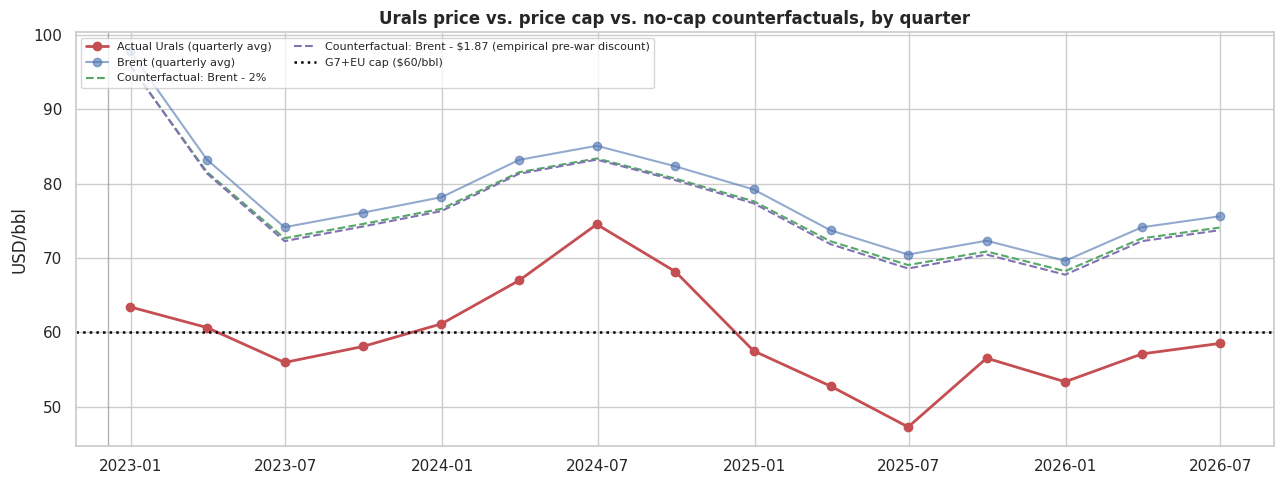

In [4]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(post_cap.date, post_cap.urals_usd_bbl, marker='o', color='#C44E52', lw=2, label='Actual Urals (quarterly avg)')
ax.plot(post_cap.date, post_cap.brent_usd_bbl, marker='o', color='#4C72B0', lw=1.5, alpha=0.6, label='Brent (quarterly avg)')
ax.plot(post_cap.date, post_cap.counterfactual_2pct, ls='--', color='#55A868', lw=1.5, label='Counterfactual: Brent - 2%')
ax.plot(post_cap.date, post_cap.counterfactual_empirical, ls='--', color='#8172B2', lw=1.5, label=f'Counterfactual: Brent - ${baseline_usd:.2f} (empirical pre-war discount)')
ax.axhline(CAP_LEVEL, color='black', ls=':', lw=1.8, label=f'G7+EU cap (${CAP_LEVEL:.0f}/bbl)')
ax.axvline(CAP_DATE, color='grey', lw=1, alpha=0.6)
ax.set_title('Urals price vs. price cap vs. no-cap counterfactuals, by quarter')
ax.set_ylabel('USD/bbl')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


## 3. Did the cap literally bind? (actual price vs. $60 level)

In [5]:
post_cap['binding'] = post_cap['urals_usd_bbl'] <= CAP_LEVEL
post_cap['pct_below_cap'] = 100*(CAP_LEVEL - post_cap['urals_usd_bbl'])/CAP_LEVEL

n_full = post_cap['post_cap_full_quarter'].sum()
n_binding = post_cap.loc[post_cap['post_cap_full_quarter'],'binding'].sum()

print(f'Full quarters since implementation: {n_full}')
print(f'Quarters where actual Urals average <= ${CAP_LEVEL:.0f} cap: {n_binding} / {n_full}')
print()
post_cap.loc[post_cap['post_cap_full_quarter'], ['quarter','urals_usd_bbl','binding','pct_below_cap']].round(2)


Full quarters since implementation: 15
Quarters where actual Urals average <= $60 cap: 9 / 15



,quarter,urals_usd_bbl,binding,pct_below_cap
35,2022Q4,63.41,False,-5.69
36,2023Q1,60.64,False,-1.07
37,2023Q2,55.94,True,6.77
38,2023Q3,58.09,True,3.18
39,2023Q4,61.14,False,-1.90
40,2024Q1,66.97,False,-11.62
41,2024Q2,74.51,False,-24.19
42,2024Q3,68.17,False,-13.61
43,2024Q4,57.49,True,4.18
44,2025Q1,52.76,True,12.06


**Interpretation of "binding".** A literal reading of "binding" is whether the
observed average price sits at/below $60. A price consistently *below* $60 is
consistent with the cap binding in the accounting-price sense, but it is also
consistent with buyers simply having strong bargaining power over discounted Russian
oil regardless of the cap (a demand-side discount, not a cap-compliance discount).
The next section separates "cap-relative" bindingness from "counterfactual-relative"
loss, which is the more informative economic question.

## 4. Discount decomposition vs. counterfactual & revenue loss

In [6]:
post_cap['loss_per_bbl_2pct'] = post_cap['counterfactual_2pct'] - post_cap['urals_usd_bbl']
post_cap['loss_per_bbl_empirical'] = post_cap['counterfactual_empirical'] - post_cap['urals_usd_bbl']
post_cap['discount_widening_vs_baseline_usd'] = post_cap['urals_brent_spread_usd'] - baseline_usd

full_q = post_cap[post_cap['post_cap_full_quarter']]
print('Average per-barrel shortfall vs. counterfactual, full quarters post-implementation:')
print(f"  vs. 2% counterfactual:        {full_q['loss_per_bbl_2pct'].mean():.2f} USD/bbl")
print(f"  vs. empirical-discount ctft:  {full_q['loss_per_bbl_empirical'].mean():.2f} USD/bbl")
print()
print('Discount widening vs. pre-war baseline (USD/bbl), by quarter:')
full_q[['quarter','urals_brent_spread_usd','discount_widening_vs_baseline_usd']].round(2)


Average per-barrel shortfall vs. counterfactual, full quarters post-implementation:
  vs. 2% counterfactual:        17.31 USD/bbl
  vs. empirical-discount ctft:  17.01 USD/bbl

Discount widening vs. pre-war baseline (USD/bbl), by quarter:


,quarter,urals_brent_spread_usd,discount_widening_vs_baseline_usd
35,2022Q4,34.39,32.52
36,2023Q1,22.59,20.72
37,2023Q2,18.19,16.32
38,2023Q3,18.00,16.13
39,2023Q4,17.03,15.16
40,2024Q1,16.21,14.35
41,2024Q2,10.56,8.70
42,2024Q3,14.15,12.28
43,2024Q4,21.71,19.85
44,2025Q1,20.95,19.08


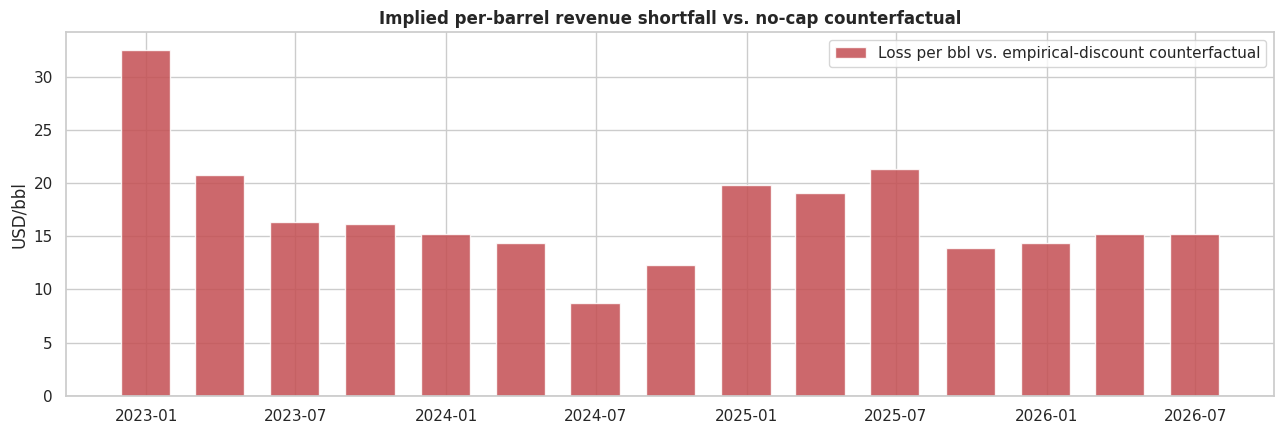

In [7]:
fig, ax = plt.subplots(figsize=(13,4.5))
ax.bar(full_q.date, full_q.loss_per_bbl_empirical, width=60, color='#C44E52', alpha=0.85,
       label='Loss per bbl vs. empirical-discount counterfactual')
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Implied per-barrel revenue shortfall vs. no-cap counterfactual')
ax.set_ylabel('USD/bbl')
ax.legend()
plt.tight_layout(); plt.show()


## 5. Aggregate revenue-loss estimate

The provided datasets do **not include export volumes** (only prices and trade
*value shares*), so converting the per-barrel shortfall into a total dollar figure
requires an external volume assumption. We use **~3.4 million barrels/day of Russian
seaborne crude exports**, a rough order-of-magnitude figure consistent with public
tanker-tracking estimates for the 2023–2024 period (e.g. Bloomberg/Kpler-based
reporting, typically in the 3.2–3.7 mb/d range) — **this single figure is a stated
assumption, not derived from the uploaded data**, and the notebook makes that
assumption a single adjustable parameter so it can be corrected if better volume data
is available.

In [8]:
ASSUMED_EXPORT_MBD = 3.4  # million barrels/day -- EXTERNAL ASSUMPTION, see markdown above

full_q = full_q.copy()
full_q['days_in_quarter'] = full_q['date'].dt.days_in_month  # placeholder, corrected below
# proper days-in-quarter count:
full_q['quarter_start'] = full_q['date'].dt.to_period('Q').dt.start_time
full_q['quarter_end'] = full_q['date'].dt.to_period('Q').dt.end_time
full_q['days_in_quarter'] = (full_q['quarter_end'] - full_q['quarter_start']).dt.days + 1

full_q['bbl_exported'] = ASSUMED_EXPORT_MBD * 1e6 * full_q['days_in_quarter']
full_q['revenue_loss_usd_bn_2pct'] = full_q['loss_per_bbl_2pct'] * full_q['bbl_exported'] / 1e9
full_q['revenue_loss_usd_bn_empirical'] = full_q['loss_per_bbl_empirical'] * full_q['bbl_exported'] / 1e9

out = full_q[['quarter','loss_per_bbl_2pct','loss_per_bbl_empirical',
              'revenue_loss_usd_bn_2pct','revenue_loss_usd_bn_empirical']].round(2)
out


,quarter,loss_per_bbl_2pct,loss_per_bbl_empirical,revenue_loss_usd_bn_2pct,revenue_loss_usd_bn_empirical
35,2022Q4,32.44,32.52,10.15,10.17
36,2023Q1,20.93,20.72,6.40,6.34
37,2023Q2,16.71,16.32,5.17,5.05
38,2023Q3,16.48,16.13,5.15,5.05
39,2023Q4,15.46,15.16,4.84,4.74
40,2024Q1,14.55,14.35,4.50,4.44
41,2024Q2,8.86,8.70,2.74,2.69
42,2024Q3,12.50,12.28,3.91,3.84
43,2024Q4,20.13,19.85,6.30,6.21
44,2025Q1,19.48,19.08,5.96,5.84


In [9]:
total_2pct = full_q['revenue_loss_usd_bn_2pct'].sum()
total_emp  = full_q['revenue_loss_usd_bn_empirical'].sum()
print(f'Cumulative implied revenue shortfall vs. counterfactual, {full_q.quarter.iloc[0]} to {full_q.quarter.iloc[-1]}:')
print(f'  vs. 2% counterfactual:       ~${total_2pct:,.1f} bn')
print(f'  vs. empirical-discount ctft: ~${total_emp:,.1f} bn')
print()
print(f'(at an assumed {ASSUMED_EXPORT_MBD} million bbl/day of seaborne crude exports -- rerun with a different')
print(' ASSUMED_EXPORT_MBD to sensitivity-test this figure)')


Cumulative implied revenue shortfall vs. counterfactual, 2022Q4 to 2026Q2:
  vs. 2% counterfactual:       ~$80.6 bn
  vs. empirical-discount ctft: ~$79.2 bn

(at an assumed 3.4 million bbl/day of seaborne crude exports -- rerun with a different
 ASSUMED_EXPORT_MBD to sensitivity-test this figure)


## 6. Caveats on interpreting "revenue loss" as a price-cap effect

1. **Attribution.** The widened discount reflects the *combined* effect of the EU
   import ban, the price cap, secondary-sanctions risk on shipping/insurance/banks,
   and the emergence of a "shadow fleet" — not the price cap alone. This notebook
   measures the **total post-2022 discount widening**, not a cleanly identified
   causal effect of the cap in isolation (that would need a design comparable to
   notebook 02's event study around the specific 5 Dec 2022 implementation date, or a
   comparison against a non-sanctioned oil-exporting country as a control).
2. **Cap "binding" is ambiguous.** Urals trading below $60 could reflect real cap
   compliance, or simply reflect the demand-side discount buyers can extract from a
   seller with limited alternative buyers — both produce the same observed price.
3. **Volume assumption.** The dollar revenue-loss figures scale linearly with the
   assumed 3.4 mb/d export volume, which is external to the provided data (see
   Section 5) — treat the $/bbl figures as the primary, data-grounded result and the
   aggregate $bn figures as an illustrative, assumption-dependent extension.
4. **ESPO / Pacific grades.** Russia's eastward-shifted ESPO exports (see
   `01_eda.ipynb`) trade at a much smaller discount than Urals and are largely outside
   G7+EU jurisdiction; the cap's effective coverage has shrunk over time as more
   volume moves to non-Western buyers/insurers, which this Urals-only analysis does
   not capture directly.
